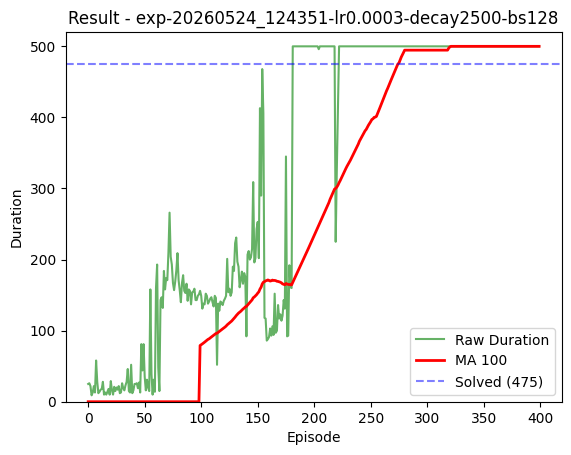

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


✓ Saved JSON: ./outputs/exp-20260524_124351-lr0.0003-decay2500-bs128/result.json
✓ Saved NPZ: ./outputs/exp-20260524_124351-lr0.0003-decay2500-bs128/result.npz
✓ Saved Model: ./outputs/exp-20260524_124351-lr0.0003-decay2500-bs128/policy_net.pt
✓ Saved Model Config: ./outputs/exp-20260524_124351-lr0.0003-decay2500-bs128/model_config.json
✓ Saved Plot: ./outputs/exp-20260524_124351-lr0.0003-decay2500-bs128/plot.png

Experiment Complete: exp-20260524_124351-lr0.0003-decay2500-bs128
Last 100 mean: 500.0
Solved @ episode: 181
Max duration: 500


In [4]:
from dqn_experiment_runner import run_experiment

# 1. RUN — auto-save ke folder
result = run_experiment(
    lr=3e-4,
    eps_decay=2500,
    num_episodes=400,
    plot_live=True,
    seed=42,
    save_dir='./outputs',
)

In [ ]:
from dqn_experiment_runner import load_experiment
# 2. LOAD eksperimen lama
old_result = load_experiment('./outputs/exp_20260524_121404_lr0.0003_decay2500_bs128')
print(old_result['stats'])

{'max_duration': 500, 'last_100_mean': 500.0, 'episodes_to_475': 181, 'total_episodes': 400}


In [6]:
from dqn_experiment_runner import list_experiments
# 3. LIST semua eksperimen
all_exp = list_experiments('./outputs')
for exp in all_exp:
    print(f"{exp['name']}: mean={exp['stats']['last_100_mean']:.1f}")

exp-20260524_124351-lr0.0003-decay2500-bs128: mean=500.0
exp_20260524_121404_lr0.0003_decay2500_bs128: mean=500.0


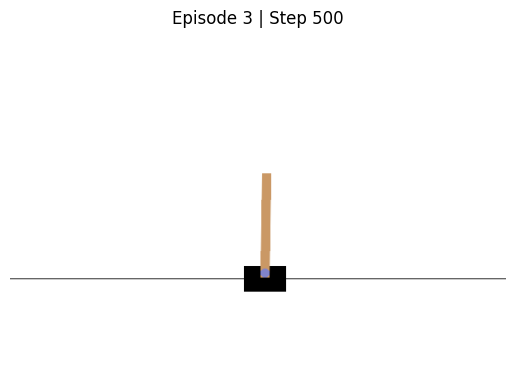

Episode 3 selesai: 500 steps


In [ ]:
from dqn_experiment_runner import show_video_from_experiment

show_video_from_experiment(
    "./outputs/exp_20260524_121404_lr0.0003_decay2500_bs128",
    num_episodes=3,
    max_steps=500,
    seed=42
)

Total eksperimen: 9
Estimasi waktu: ~54 menit (dengan 350 ep)

>>> Eksperimen 1/9: lr=0.0001, eps_decay=1000

Starting Experiment: grid_lr0.0001_decay1000
Save directory: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000

✓ Saved JSON: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000/result.json
✓ Saved NPZ: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000/result.npz
✓ Saved Model: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000/policy_net.pt
✓ Saved Model Config: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000/model_config.json
✓ Saved Plot: ./outputs/run-20260524_133824/grid_lr0.0001_decay1000/plot.png

Experiment Complete: grid_lr0.0001_decay1000
Last 100 mean: 500.0
Solved @ episode: 191
Max duration: 500
    Last 100 mean: 500.0
    Solved @ ep: 191
    Max duration: 500

>>> Eksperimen 2/9: lr=0.0001, eps_decay=2500

Starting Experiment: grid_lr0.0001_decay2500
Save directory: ./outputs/run-20260524_133824/grid_lr0.0001_decay2500

✓ Saved JSON: ./outputs

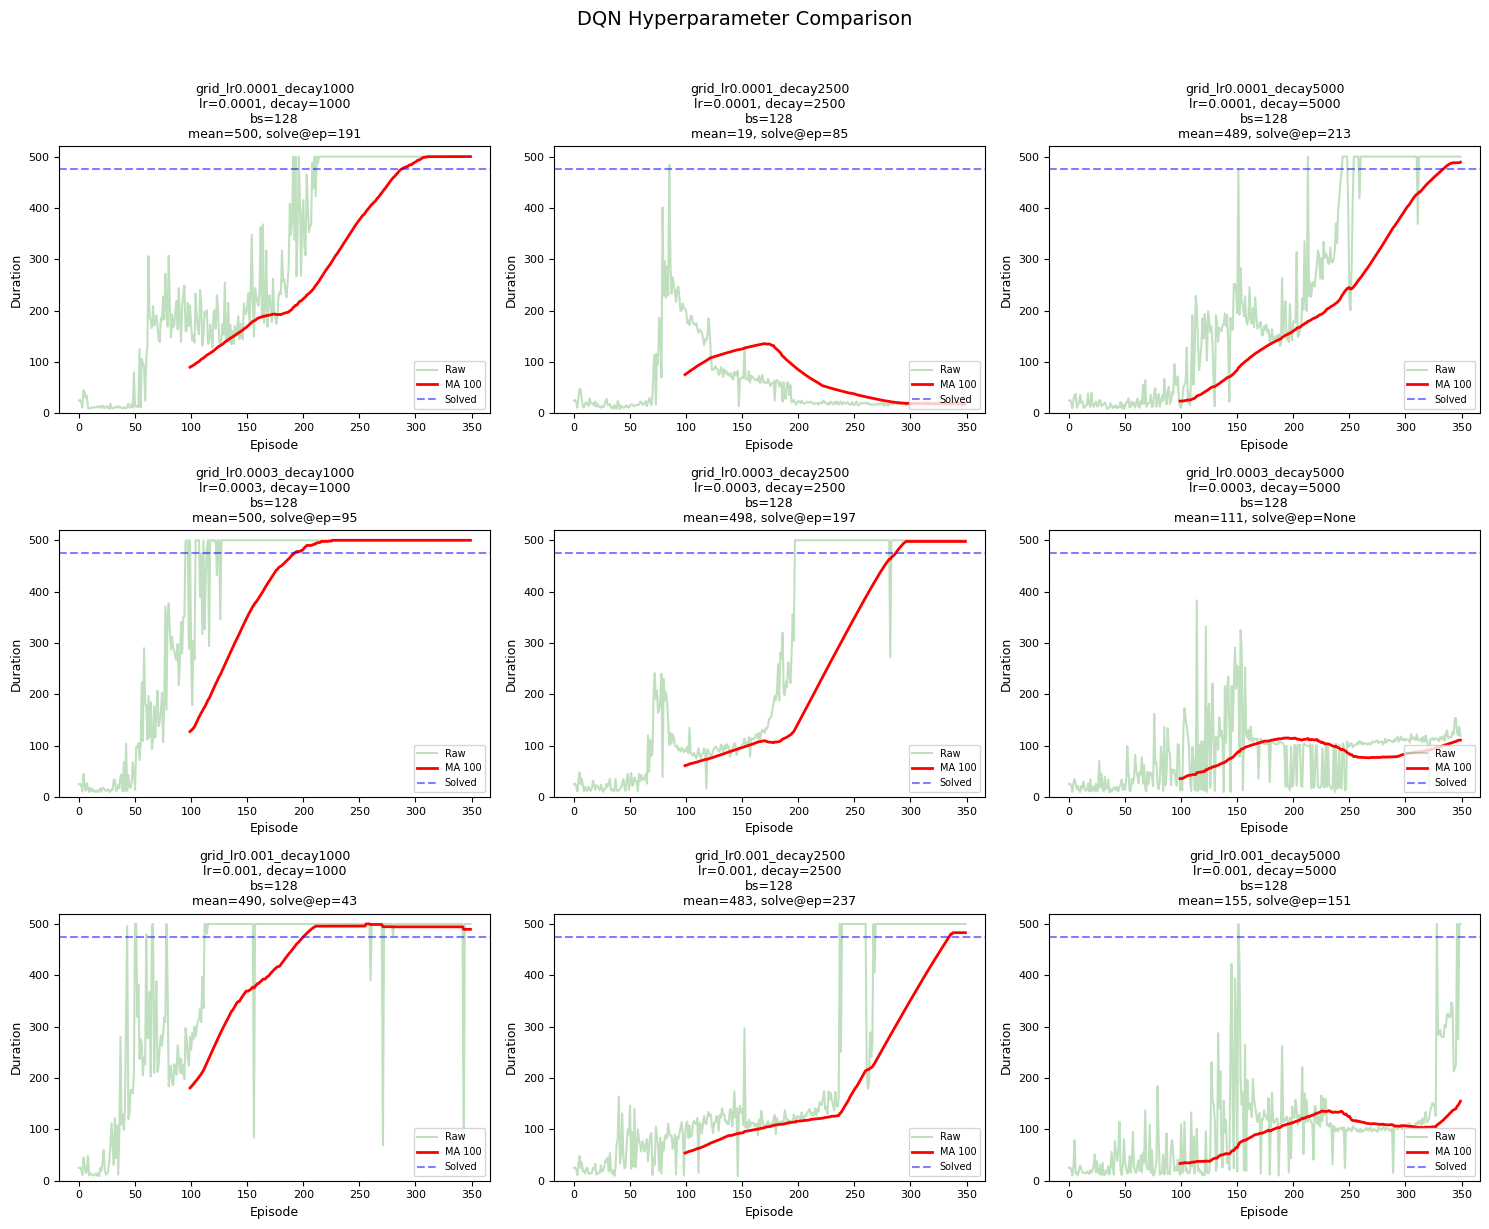

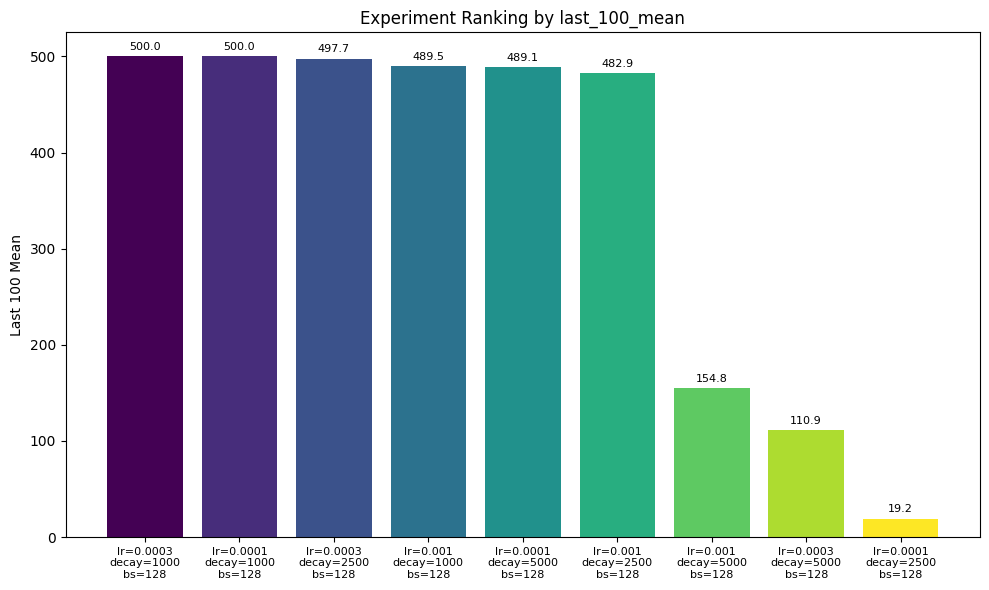


RANKING BY SPEED TO SOLVE:
1. lr=0.001, decay=1000 | solve@ep=43
2. lr=0.0001, decay=2500 | solve@ep=85
3. lr=0.0003, decay=1000 | solve@ep=95
4. lr=0.001, decay=5000 | solve@ep=151
5. lr=0.0001, decay=1000 | solve@ep=191
6. lr=0.0003, decay=2500 | solve@ep=197
7. lr=0.0001, decay=5000 | solve@ep=213
8. lr=0.001, decay=2500 | solve@ep=237

Summary saved to outputs/run-20260524_133824/summary/grid_search_summary.json


In [8]:
"""
Grid Search DQN CartPole — Optimized untuk 1-1.5 jam
Top 2 parameter paling berpengaruh: lr × eps_decay
"""

from dqn_experiment_runner import run_experiment, plot_experiments_comparison, plot_ranking_bar
import json
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# ============================================
# KONFIGURASI GRID SEARCH
# ============================================

# Fixed parameters (baseline)
FIXED_PARAMS = {
    'batch_size': 128,
    'gamma': 0.99,
    'eps_start': 0.9,
    'eps_end': 0.01,
    'tau': 0.005,
    'memory_size': 10000,
}

# Grid search parameters
LR_VALUES = [1e-4, 3e-4, 1e-3]
EPS_DECAY_VALUES = [1000, 2500, 5000]

# Episode fixed — 350 cukup untuk CartPole
NUM_EPISODES = 350
HIDDEN_SIZE = 256
SEED = 42
PLOT_LIVE = False

# ============================================
# RUN GRID SEARCH
# ============================================

results = []
experiment_configs = []

# Generate semua kombinasi
for lr in LR_VALUES:
    for eps_decay in EPS_DECAY_VALUES:
        config = {
            **FIXED_PARAMS,
            'lr': lr,
            'eps_decay': eps_decay,
            'num_episodes': NUM_EPISODES,
            'seed': SEED,
            'hidden_size': HIDDEN_SIZE,
            'plot_live': PLOT_LIVE,
            'save_dir': f"./outputs/run-{timestamp}",
            'save_model': True,
            'experiment_name': f"grid_lr{lr}_decay{eps_decay}",
        }
        experiment_configs.append(config)

print(f"Total eksperimen: {len(experiment_configs)}")
print(f"Estimasi waktu: ~{len(experiment_configs) * 6} menit (dengan 350 ep)")
print("=" * 60)

for i, config in enumerate(experiment_configs, 1):
    print(f"\n>>> Eksperimen {i}/{len(experiment_configs)}: lr={config['lr']}, eps_decay={config['eps_decay']}")

    result = run_experiment(**config)
    results.append(result)

    print(f"    Last 100 mean: {result['stats']['last_100_mean']:.1f}")
    print(f"    Solved @ ep: {result['stats']['episodes_to_475']}")
    print(f"    Max duration: {result['stats']['max_duration']}")

# ============================================
# ANALISIS HASIL
# ============================================

print("\n" + "=" * 60)
print("RANKING HASIL")
print("=" * 60)

# Sort by last_100_mean (descending)
ranked = sorted(results, key=lambda x: x['stats']['last_100_mean'], reverse=True)

for i, r in enumerate(ranked, 1):
    p = r['hyperparameters']
    s = r['stats']
    print(f"{i}. lr={p['lr']}, decay={p['eps_decay']} | "
          f"mean={s['last_100_mean']:.1f} | "
          f"solve@ep={s['episodes_to_475']} | "
          f"max={s['max_duration']}")

# Best config
best = ranked[0]
print(f"\nBEST CONFIG: lr={best['hyperparameters']['lr']}, "
      f"eps_decay={best['hyperparameters']['eps_decay']}")

# ============================================
# VISUALISASI
# ============================================

# 1. Comparison plot semua eksperimen
plot_experiments_comparison(
    results,
    save_path=f"outputs/run-{timestamp}/summary/grid_search_comparison.png",
    show=True,
    max_cols=3
)

# 2. Ranking bar chart
plot_ranking_bar(
    results,
    metric='last_100_mean',
    save_path=f"outputs/run-{timestamp}/summary/grid_search_ranking.png",
    show=True
)

# 3. Ranking by episodes_to_solve (lower is better)
# Filter yang solved saja
solved_results = [r for r in results if r['stats']['episodes_to_475'] is not None]
if solved_results:
    solved_ranked = sorted(solved_results, key=lambda x: x['stats']['episodes_to_475'])
    print("\nRANKING BY SPEED TO SOLVE:")
    for i, r in enumerate(solved_ranked, 1):
        p = r['hyperparameters']
        s = r['stats']
        print(f"{i}. lr={p['lr']}, decay={p['eps_decay']} | "
              f"solve@ep={s['episodes_to_475']}")

# ============================================
# SAVE SUMMARY
# ============================================

summary = {
    'fixed_params': FIXED_PARAMS,
    'grid_params': {'lr': LR_VALUES, 'eps_decay': EPS_DECAY_VALUES},
    'num_episodes': NUM_EPISODES,
    'results': [
        {
            'name': r['experiment_name'],
            'hyperparameters': {k: str(v) if isinstance(v, float) else v 
                              for k, v in r['hyperparameters'].items()},
            'stats': r['stats']
        }
        for r in ranked
    ]
}

summary_path = f"outputs/run-{timestamp}/summary/grid_search_summary.json"
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(f"\nSummary saved to {summary_path}")

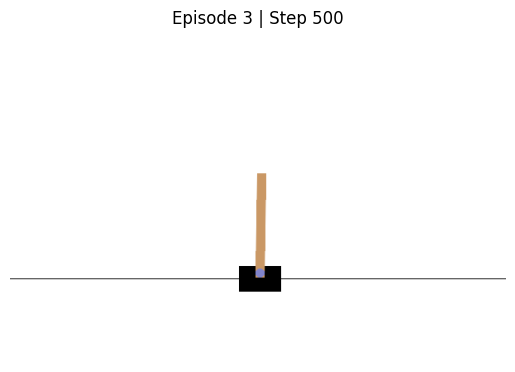

Episode 3 selesai: 500 steps


In [9]:
from dqn_experiment_runner import show_video_from_experiment

show_video_from_experiment(
    "./outputs/run-20260524_133824/grid_lr0.0003_decay1000",
    num_episodes=3,
    max_steps=500,
    seed=42
)

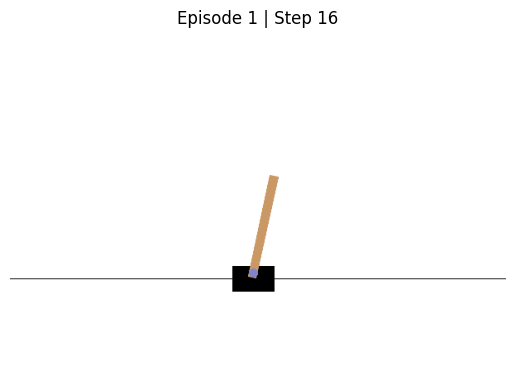

Episode 1 selesai: 16 steps


In [11]:
from dqn_experiment_runner import show_video_from_experiment

show_video_from_experiment(
    "./outputs/run-20260524_133824/grid_lr0.0001_decay2500",
    max_steps=500,
    seed=42
)